# Generic Backbone

This notebook demonstrates the use of a custom class called `GenericBackbone`, developed to simplify the process of extracting features and predictions from pretrained vision models available in torchvision.

The class was designed as part of the "Logo Recognition and Similarity Search" project to provide a reusable, modular interface for integrating pretrained backbones like ResNet50 into various stages of the pipeline.

### Key functionality includes:

- Extracting features from any intermediate layer in the model by specifying `return_layers`.
- Optionally removing final layers like classification heads (`remove_layers`).
- Freezing the backbone parameters for inference or fine-tuning scenarios.
- Supporting batch input using standardized transforms and integration with the Hugging Face Datasets library.
- Generating top-k class predictions using pretrained weights for benchmarking purposes.

In this project specifically, the `GenericBackbone` enables:

1. Running experiments with different pretrained models to compare their impact on feature quality and downstream performance.
2. Extracting features from arbitrary layers such as `avgpool` or deeper convolutional blocks for use in Triplet Loss training or similarity search indexing.
3. Using top-k predictions from the `fc` layer (pretrained on ImageNet) to evaluate how well general-purpose models can classify logos or serve as a reference baseline.
4. Producing embeddings and predictions in a structured format compatible with `datasets.map()`, which simplifies integration and scaling.

Overall, this class abstracts away repetitive setup code and makes it easier to plug vision models into training, evaluation, and indexing workflows.


## Import Libraries

In [2]:
!pip install datasets -q

import os
import datasets
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import torch
from PIL import Image
import torchvision
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Configuration

In [5]:
import os
from pathlib import Path
import torch


class Config:
    """
    Configuration class for the project.
    """
    # ========== Base Paths ==========
    project_name = "logo_recognition_similarity_search_project"
    base_dir = Path("/content/drive/MyDrive")/project_name
    output_dir = base_dir / "output"
    cache_dir = base_dir / "cache"

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    # ========== Dataset ==========
    dataset_path = "mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Dataset-V2"
    dataset_cache_dir = cache_dir / dataset_path.split("/")[-1]
    category_indices_cache_dir = cache_dir / "Category-Indices" / dataset_path.split("/")[-1]
    batch_size = 2000
    num_shards = 2
    shard_index = 1
    shards_base_repo = "mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Dataset"
    shard_repo = lambda self, index: f"{self.shards_base_repo}-shard{index}-of-{self.num_shards}"

    # ========== Runtime ==========
    device = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers = os.cpu_count()
    seed = 42


# Create Configuration Object
cfg = Config()

## Load Dataset

In [ ]:
# from datasets import load_dataset

# ds = load_dataset(path = cfg.dataset_path,
#                    split = "train",
#                    cache_dir = cfg.dataset_cache_dir,
#                   ).remove_columns(['image_embedding'])

# ds

In [ ]:
from datasets import load_from_disk

ds = load_from_disk(cfg.dataset_cache_dir)['train'].remove_columns(['image_embedding'])
ds

Loading dataset from disk:   0%|          | 0/192 [00:00<?, ?it/s]

Dataset({
    features: ['id', 'path', 'path_category', 'prompt', 'image', 'category'],
    num_rows: 1777584
})

In [ ]:
ds.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'path_category': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'image': Image(mode='RGB', decode=True, id=None),
 'category': Value(dtype='int32', id=None)}

In [ ]:
ds[0]

{'id': '1104391803911815278',
 'path': 'images/00/00/1104391803911815278_0_0.png',
 'path_category': 'images_category/category_197906/1104391803911815278_0_0.png',
 'prompt': 'cute simple baby shark logo for company',
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=128x128>,
 'category': 197906}

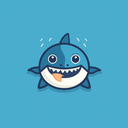

In [ ]:
ds[0]['image']

## GenericBackbone Class Definition

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Compose
from typing import List, Union, Optional, Dict
from PIL import Image


class GenericBackbone(nn.Module):
    def __init__(
        self,
        model: nn.Module,
        weights_meta: dict,
        transform: Compose,
        freeze: bool = True,
        return_layers: Optional[List[str]] = None,
        remove_layers: Optional[List[str]] = None,
        device: Optional[torch.device] = None,
    ):
        """
        Generic backbone wrapper for torchvision vision models.

        Args:
            model: Torchvision model (e.g., resnet50).
            weights_meta: Metadata from the weights object.
            transform: Recommended transform for input preprocessing.
            freeze: Whether to freeze model weights (default: True).
            return_layers: List of intermediate layers to capture via hooks.
            remove_layers: List of layer names to remove from model (e.g. ["fc"]).
            device: Device to use.
        """
        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.transform = transform
        self.weights_meta = weights_meta
        self.return_layers = return_layers or []
        self.remove_layers = remove_layers or []


        # Apply remove_layers dynamically
        for layer_name in self.remove_layers:
            if hasattr(model, layer_name):
                setattr(model, layer_name, nn.Identity())

        self.model = model.to(self.device).eval()

        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False

        # Prepare storage for hook outputs
        self._outputs: Dict[str, torch.Tensor] = {}
        self._register_hooks()

    def _register_hooks(self):
        """
        Register forward hooks for layers specified in return_layers.
        """
        for name, module in self.model.named_modules():
            if name in self.return_layers:
                module.register_forward_hook(self._get_hook(name))

    def _get_hook(self, name: str):
        def hook(module, input, output):
            self._outputs[name] = output.detach().cpu()
        return hook

    def _prepare_input(self, images: Union[Image.Image, List[Image.Image]]) -> torch.Tensor:
        """
        Transform PIL image(s) and prepare a batch tensor.
        """
        if isinstance(images, Image.Image):
            images = [images]
        return torch.stack([self.transform(img) for img in images]).to(self.device)


    def _get_last_valid_layer_name(self) -> Optional[str]:
        """
        Return the name of the last non-Identity layer in the model.
        """
        for name, module in reversed(list(self.model.named_modules())):
            if not isinstance(module, nn.Identity):
                return name
        return None


    def forward(self,images: Union[Image.Image, List[Image.Image]]) -> Dict[str, torch.Tensor]:
        """
        Forward pass through the model.

        Returns:
            - If return_layers are set: returns a dict of requested layer outputs.
            - If return_layers is empty: returns dict with model output under key <final_layer_name>.
        """
        self._outputs = {}

        try:
            x = self._prepare_input(images)

            with torch.no_grad():
                output = self.model(x).cpu()

            if not self.return_layers:
                last_layer_name = self._get_last_valid_layer_name()
                return {last_layer_name: output}

            return self._outputs

        except Exception as e:
            print(f"[Forward Error] {e}")
            raise e


    def predict_topk(self,logits: torch.Tensor,topk: int = 5) -> Union[List[tuple], List[List[tuple]]]:
        """
        Given model logits, return top-k class predictions and probabilities.

        Args:
            logits: Output from model (shape: [B, num_classes] or [num_classes]).
            topk: Number of top classes to return.

        Returns:
            List of {"label": ..., "score": ...} for each image.
        """
        single = logits.dim() == 1
        if single:
            logits = logits.unsqueeze(0)

        probs = F.softmax(logits, dim=1)
        values, indices = torch.topk(probs, k=topk, dim=1)

        labels = self.weights_meta["categories"]

        results = [
            [{"label": labels[idx], "score": round(values[i].item(), 5)} for i, idx in enumerate(idxs)]
            for values, idxs in zip(values, indices)
        ]

        return results[0] if single else results


## Load Pretrained ResNet50 & Initialize Backbone

In [ ]:
# Load a pretrained ResNet50 model with ImageNet V2 weights
# Wrap the model using GenericBackbone to extract features from 'avgpool' and logits from 'fc'

from torchvision import models

weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)

backbone = GenericBackbone(
    model=model,
    weights_meta=weights.meta,
    transform=weights.transforms(),
    freeze=True,
    remove_layers=[],
    return_layers=["avgpool", "fc"],
    device=cfg.device
)

backbone

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 144MB/s]


GenericBackbone(
  (transform): ImageClassification(
      crop_size=[224]
      resize_size=[232]
      mean=[0.485, 0.456, 0.406]
      std=[0.229, 0.224, 0.225]
      interpolation=InterpolationMode.BILINEAR
  )
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1)

## Define Batch Processing Function

In [ ]:
# Define a batch-level processing function that:
# 1. Passes images through the backbone to extract avgpool features and fc logits
# 2. Converts avgpool features to list format
# 3. Computes top-k predictions from the logits and returns everything as a batch

def process_batch(batch, model: GenericBackbone, topk: int = 5):
    try:
        output = model(batch["image"])
        batch['resnet50_embedding'] = output["avgpool"]
        batch['resnet50_class'] = model.predict_topk(output["fc"], topk=topk)
        return batch

    except Exception as e:
        print(f"[Process Batch Error] {e}")
        def_error = [None] * len(batch["image"])
        batch['resnet50_embedding'] = def_error
        batch['resnet50_class'] = def_error
        return batch


def process_batch(batch, model: GenericBackbone, topk: int = 5):
    try:
        output = model(batch["image"])
        batch['resnet50_embedding'] = output["avgpool"]
        batch['resnet50_class'] = model.predict_topk(output["fc"], topk=topk)
        return batch

    except Exception as e:
        print(f"[Process Batch Error] {e}")
        def_error = [None] * len(batch["image"])
        batch['resnet50_embedding'] =  def_error
        batch['resnet50_class'] = def_error
        return batch

## Apply Backbone to Dataset

In [ ]:
# Prepare a partial function with model and topk arguments fixed
# This function will be used with Hugging Face's .map() to process the dataset in batches

from functools import partial

map_fn = partial(process_batch, model=backbone, topk=5)

In [ ]:
# Select the first n samples from the dataset and apply the process_batch function
# Features and top-k class predictions will be added as new columns

shard_ds = ds.shard(num_shards=cfg.num_shards, index=cfg.shard_index, contiguous=True)

shard_ds = shard_ds.map(map_fn,
                        batched = True,
                        batch_size = cfg.batch_size,
                        desc = "Extracting ResNet50 embeddings and classes from shard {}".format(cfg.shard_index)
                        )

shard_ds

Extracting ResNet50 embeddings and classes from shard 1:   0%|          | 0/500000 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'path', 'path_category', 'prompt', 'image', 'category', 'resnet50_embedding', 'resnet50_class'],
    num_rows: 500000
})

## Inspect Processed Dataset

In [ ]:
# Inspect the structure of the dataset

shard_ds.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'path_category': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'image': Image(mode='RGB', decode=True, id=None),
 'category': Value(dtype='int32', id=None),
 'resnet50_embedding': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'resnet50_class': [{'label': Value(dtype='string', id=None),
   'score': Value(dtype='float64', id=None)}]}

In [ ]:
# Inspect the verify the output of resnet50_embedding and resnet50_class columns

(
 len(shard_ds[0]['resnet50_embedding']),
 len(shard_ds[0]['resnet50_class']),
 shard_ds[0]['resnet50_class']
)

(2048,
 5,
 [{'label': 'street sign', 'score': 0.11554},
  {'label': 'shield', 'score': 0.06177},
  {'label': 'letter opener', 'score': 0.03435},
  {'label': 'drumstick', 'score': 0.03225},
  {'label': 'bolo tie', 'score': 0.02527}])

## Push Dataset to Hugging Face Hub

In [ ]:
# Push the updated dataset to a private repository on the Hugging Face Hub

shard_repo_id = cfg.shard_repo(index=cfg.shard_index)

shard_ds.push_to_hub(
    repo_id = shard_repo_id,
    private = True,
)

## Concatenate Shards

In [32]:
# # Concatenate Shards

from datasets import load_dataset, concatenate_datasets

shards = [
    load_dataset(cfg.shard_repo(index=i), split="train")
    for i in range(cfg.num_shards)
    ]

ds_full = concatenate_datasets(shards)

ds_full

Dataset({
    features: ['id', 'path', 'path_category', 'prompt', 'image', 'category', 'resnet50_embedding', 'resnet50_class'],
    num_rows: 1777584
})

In [31]:
ds_full.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'path_category': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'image': Image(mode='RGB', decode=True, id=None),
 'category': Value(dtype='int32', id=None),
 'resnet50_embedding': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'resnet50_class': [{'label': Value(dtype='string', id=None),
   'score': Value(dtype='float64', id=None)}]}

In [ ]:
ds_full.push_to_hub(
    repo_id = cfg.shards_base_repo,
    private = True,
)

## Load Processed Dataset

In [ ]:
from datasets import load_dataset

ds = load_dataset(path = cfg.shards_base_repo, split = "train")

In [7]:
ds

Dataset({
    features: ['id', 'path', 'path_category', 'prompt', 'image', 'category', 'resnet50_embedding', 'resnet50_class'],
    num_rows: 1777584
})

In [8]:
ds.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'path_category': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'image': Image(mode='RGB', decode=True, id=None),
 'category': Value(dtype='int32', id=None),
 'resnet50_embedding': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'resnet50_class': [{'label': Value(dtype='string', id=None),
   'score': Value(dtype='float64', id=None)}]}

In [11]:
from pathlib import Path

dataset_cache_dir = cfg.cache_dir / cfg.shards_base_repo.split("/")[-1]

ds.save_to_disk(dataset_cache_dir)

Saving the dataset (0/164 shards):   0%|          | 0/1777584 [00:00<?, ? examples/s]

## Disconnect & Delete Colab Runtime

In [ ]:
# Disconnect and delete the current runtime in Google Colab
from google.colab import runtime

runtime.unassign()